In [1]:
import pandas as pd 
import numpy as np 
from glob import glob
import os
import geopandas as gpd

import csv
import json

from ast import literal_eval

/usr/local/lib/python3.8/dist-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.2-CAPI-1.17.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/tmp/tmp.tVi4ehQkOs/ipykernel_1765963/2557301808.py:5: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration

In [14]:
stats = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats.csv")

# to read in the model counts col as dictionaries
stats["model_counts"] = stats["model_counts"].apply(literal_eval)

print("all rows (not cleaned)")
print(len(stats))

stats.head(4)

stats.columns

print(np.unique(stats["type"]))

stats_wpreds = stats[stats["model_counts"]!={}].reset_index()

print("rows WITH camera preds")
print(len(stats_wpreds))


all rows (not cleaned)
96003
['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather']
rows WITH camera preds
58679


In [3]:
# Add columns to dataframe for easy analysis and plotting

catslist = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

#### Add columns for each cat (counts)
def row_amt_bycat(row):
    rowdict = row["model_counts"]
    totalcams = np.sum(rowdict.values)
    cat_counts = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_counts.append(catval)
    return cat_counts

stats_wpreds["cat_counts"] = stats_wpreds.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols
new_cols_df = pd.DataFrame(stats_wpreds['cat_counts'].tolist(), columns=catslist)

stats_wpreds_catcols = pd.concat([stats_wpreds, new_cols_df], axis=1)

# Add total cams so that we can get percentages, proportion
totalcams = stats_wpreds_catcols[catslist].sum(axis=1).tolist()

stats_wpreds_catcols["totalcams"] = totalcams

#### Add columns for each cat (percentages)
def row_amt_bycat(row):
    cat_proportions = []
    for cat in catslist:
        perc = np.round(row[cat]/row["totalcams"],4)
        cat_proportions.append(perc)
    return cat_proportions

stats_wpreds_catcols["cat_percents"] = stats_wpreds_catcols.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols

catslist_perc = [f"{c}_perc" for c in catslist]
new_cols_df2 = pd.DataFrame(stats_wpreds_catcols['cat_percents'].tolist(), columns=catslist_perc)

stats_wpreds_allinfo = pd.concat([stats_wpreds_catcols, new_cols_df2], axis=1)

# sort df by time

stats_wpreds_allinfo = stats_wpreds_allinfo.sort_values("timestamp")

stats_wpreds_allinfo['timestep'] = range(1, len(stats_wpreds_allinfo)+1) # we sorted by timestamp but it's a string, so add col of integers representing time steps through duration of event


In [9]:
stats_wpreds_allinfo[75:100]

,index,event,episode,type,location,wfo,timestamp,model_counts,cat_counts,snow_severe,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
36,36,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1505,"{'poor_viz': 1, 'snow': 2, 'snow_severe': 56}","[56, 2, 0, 0, 1]",56,...,0,1,59,"[0.9492, 0.0339, 0.0, 0.0, 0.0169]",0.9492,0.0339,0.0,0.0,0.0169,76
104,183,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1510,"{'snow': 1, 'snow_severe': 55}","[55, 1, 0, 0, 0]",55,...,0,0,56,"[0.9821, 0.0179, 0.0, 0.0, 0.0]",0.9821,0.0179,0.0,0.0,0.0000,77
29,29,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1510,"{'poor_viz': 1, 'snow': 2, 'snow_severe': 56}","[56, 2, 0, 0, 1]",56,...,0,1,59,"[0.9492, 0.0339, 0.0, 0.0, 0.0169]",0.9492,0.0339,0.0,0.0,0.0169,78
60,60,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1515,"{'poor_viz': 1, 'snow': 2, 'snow_severe': 56}","[56, 2, 0, 0, 1]",56,...,0,1,59,"[0.9492, 0.0339, 0.0, 0.0, 0.0169]",0.9492,0.0339,0.0,0.0,0.0169,79
133,212,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1515,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,80
23,23,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1520,"{'poor_viz': 1, 'snow': 2, 'snow_severe': 56}","[56, 2, 0, 0, 1]",56,...,0,1,59,"[0.9492, 0.0339, 0.0, 0.0, 0.0169]",0.9492,0.0339,0.0,0.0,0.0169,81
99,178,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1520,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,82
122,201,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1525,"{'snow': 1, 'snow_severe': 55}","[55, 1, 0, 0, 0]",55,...,0,0,56,"[0.9821, 0.0179, 0.0, 0.0, 0.0]",0.9821,0.0179,0.0,0.0,0.0000,83
49,49,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1525,"{'poor_viz': 1, 'snow': 2, 'snow_severe': 56}","[56, 2, 0, 0, 1]",56,...,0,1,59,"[0.9492, 0.0339, 0.0, 0.0, 0.0169]",0.9492,0.0339,0.0,0.0,0.0169,84
125,204,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1530,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,85


In [4]:
stats_wpreds_allinfo.head(5)

,index,event,episode,type,location,wfo,timestamp,model_counts,cat_counts,snow_severe,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
0,0,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1200,"{'poor_viz': 5, 'snow_severe': 54}","[54, 0, 0, 0, 5]",54,...,0,5,59,"[0.9153, 0.0, 0.0, 0.0, 0.0847]",0.9153,0.0,0.0,0.0,0.0847,1
79,158,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1200,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0,0.0,0.0,0.0000,2
137,216,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1205,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0,0.0,0.0,0.0000,3
64,64,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,"{'poor_viz': 3, 'snow_severe': 56}","[56, 0, 0, 0, 3]",56,...,0,3,59,"[0.9492, 0.0, 0.0, 0.0, 0.0508]",0.9492,0.0,0.0,0.0,0.0508,4
145,224,996910,165058,Blizzard,NORTHWEST SUFFOLK,OKX,20220129_1210,{'snow_severe': 56},"[56, 0, 0, 0, 0]",56,...,0,0,56,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0,0.0,0.0,0.0000,5


In [32]:
#### Informative data structure information

#### For reference: the episode is the  broad weather system, which contains multiple events (different locations within the episode), and events contain multiple timestamps lasting the duration of the event

#### Check if each event maps to exactly one value in "location" and "wfo" - Yes
mapping_check = stats_wpreds.groupby("event")[["location", "wfo"]].nunique()
# print(mapping_check)
is_consistent = (mapping_check == 1).all().all()
print(is_consistent)  # True if consistent

         location  wfo
event                 
996866          1    1
996910          1    1
1070864         1    1
1070865         1    1
1070866         1    1
...           ...  ...
1273926         1    1
1273927         1    1
1273958         1    1
1274158         1    1
1274159         1    1

[471 rows x 2 columns]
True


In [5]:
# Aggregate across all event occurances of a specific type (all "Blizzard" occurances)

# only look at event locations where there were cams
e_type = stats_wpreds[stats_wpreds["type"]=="Blizzard"]

print(e_type.dtypes)

e_type

eps = len(np.unique(e_type["episode"]))
evs = len(np.unique(e_type["event"]))

print(f"number of unique episodes (the broad weather system): {eps}")
print(f"number of unique events (locations within an episode): {evs}")

# One location has multiple model runs in it, lasting the duration of the event, aggregate across the times, too

index            int64
event            int64
episode          int64
type            object
location        object
wfo             object
timestamp       object
model_counts    object
cat_counts      object
dtype: object
number of unique episodes (the broad weather system): 2
number of unique events (locations within an episode): 8


In [6]:
# Investigation 1
# Start by looking at one event (which is a location within an episode) and how the model preds change during the duration of an event 
# see block above, Informative data structure information for more data info

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["event"]==996866]


In [7]:
event_one_example

,index,event,episode,type,location,wfo,timestamp,model_counts,cat_counts,snow_severe,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
0,0,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1200,"{'poor_viz': 5, 'snow_severe': 54}","[54, 0, 0, 0, 5]",54,...,0,5,59,"[0.9153, 0.0, 0.0, 0.0, 0.0847]",0.9153,0.0000,0.0,0.0,0.0847,1
64,64,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,"{'poor_viz': 3, 'snow_severe': 56}","[56, 0, 0, 0, 3]",56,...,0,3,59,"[0.9492, 0.0, 0.0, 0.0, 0.0508]",0.9492,0.0000,0.0,0.0,0.0508,4
72,72,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1210,"{'poor_viz': 4, 'snow': 1, 'snow_severe': 54}","[54, 1, 0, 0, 4]",54,...,0,4,59,"[0.9153, 0.0169, 0.0, 0.0, 0.0678]",0.9153,0.0169,0.0,0.0,0.0678,6
69,69,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1215,"{'poor_viz': 4, 'snow': 2, 'snow_severe': 53}","[53, 2, 0, 0, 4]",53,...,0,4,59,"[0.8983, 0.0339, 0.0, 0.0, 0.0678]",0.8983,0.0339,0.0,0.0,0.0678,7
75,75,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1220,"{'poor_viz': 4, 'snow': 1, 'snow_severe': 54}","[54, 1, 0, 0, 4]",54,...,0,4,59,"[0.9153, 0.0169, 0.0, 0.0, 0.0678]",0.9153,0.0169,0.0,0.0,0.0678,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,37,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1810,{'snow_severe': 59},"[59, 0, 0, 0, 0]",59,...,0,0,59,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,148
21,21,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1815,"{'snow': 1, 'snow_severe': 58}","[58, 1, 0, 0, 0]",58,...,0,0,59,"[0.9831, 0.0169, 0.0, 0.0, 0.0]",0.9831,0.0169,0.0,0.0,0.0000,149
9,9,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1820,{'snow_severe': 59},"[59, 0, 0, 0, 0]",59,...,0,0,59,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,150
40,40,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1825,{'snow_severe': 59},"[59, 0, 0, 0, 0]",59,...,0,0,59,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0,0.0,0.0000,151


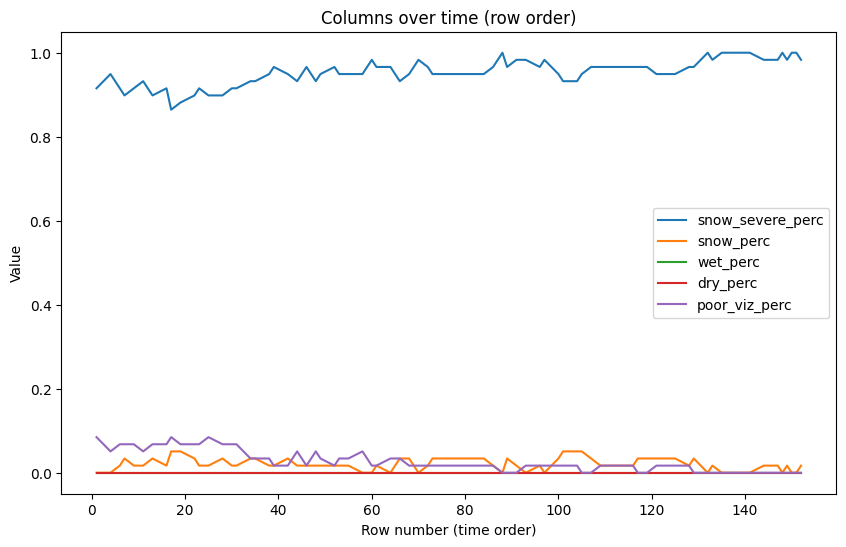

In [8]:
import matplotlib.pyplot as plt

cols = catslist_perc#['snow_perc', 'wet_perc', 'dry_perc', 'poor_viz_perc']

plt.figure(figsize=(10,6))
for col in cols:
    plt.plot(event_one_example['timestep'], event_one_example[col], label=col)

plt.xlabel('Row number (time order)')
plt.ylabel('Value')
plt.title('Columns over time (row order)')
plt.legend()
plt.show()

In [13]:
# Investigation 1b:  Maybe it turned into a winter storm warning after?? Look at the df by location and time (dont just zoom into the blizzard event)

# it didn't appear to turn into anything else after it. However, that doesn't mean that can't happen -- something to look into / organize

# go back to main df and grab that location | wfo
exb = stats_wpreds_allinfo[((stats_wpreds_allinfo["location"] == "SOUTHWEST SUFFOLK" ) & (stats_wpreds_allinfo["wfo"]=="OKX"))].sort_values("timestamp")

print(len(exb))
exb[75:100]

231


,index,event,episode,type,location,wfo,timestamp,model_counts,cat_counts,snow_severe,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
21,21,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1815,"{'snow': 1, 'snow_severe': 58}","[58, 1, 0, 0, 0]",58,...,0,0,59,"[0.9831, 0.0169, 0.0, 0.0, 0.0]",0.9831,0.0169,0.0000,0.0,0.0000,149
9,9,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1820,{'snow_severe': 59},"[59, 0, 0, 0, 0]",59,...,0,0,59,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0000,0.0,0.0000,150
40,40,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1825,{'snow_severe': 59},"[59, 0, 0, 0, 0]",59,...,0,0,59,"[1.0, 0.0, 0.0, 0.0, 0.0]",1.0000,0.0000,0.0000,0.0,0.0000,151
26,26,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1830,"{'snow': 1, 'snow_severe': 58}","[58, 1, 0, 0, 0]",58,...,0,0,59,"[0.9831, 0.0169, 0.0, 0.0, 0.0]",0.9831,0.0169,0.0000,0.0,0.0000,152
43060,70107,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1100,"{'poor_viz': 2, 'snow': 11, 'wet': 46}","[0, 11, 46, 0, 2]",0,...,0,2,59,"[0.0, 0.1864, 0.7797, 0.0, 0.0339]",0.0000,0.1864,0.7797,0.0,0.0339,12050
43073,70120,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1115,"{'poor_viz': 1, 'snow': 14, 'wet': 44}","[0, 14, 44, 0, 1]",0,...,0,1,59,"[0.0, 0.2373, 0.7458, 0.0, 0.0169]",0.0000,0.2373,0.7458,0.0,0.0169,12077
43085,70132,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1130,"{'poor_viz': 1, 'snow': 4, 'snow_severe': 10, ...","[10, 4, 44, 0, 1]",10,...,0,1,59,"[0.1695, 0.0678, 0.7458, 0.0, 0.0169]",0.1695,0.0678,0.7458,0.0,0.0169,12083
43088,70135,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1145,"{'poor_viz': 2, 'snow': 6, 'snow_severe': 10, ...","[10, 6, 41, 0, 2]",10,...,0,2,59,"[0.1695, 0.1017, 0.6949, 0.0, 0.0339]",0.1695,0.1017,0.6949,0.0,0.0339,12103
43057,70104,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1200,"{'poor_viz': 6, 'snow': 7, 'snow_severe': 13, ...","[13, 7, 33, 0, 6]",13,...,0,6,59,"[0.2203, 0.1186, 0.5593, 0.0, 0.1017]",0.2203,0.1186,0.5593,0.0,0.1017,12124
43083,70130,1152284,187612,Winter Weather,SOUTHWEST SUFFOLK,OKX,20240213_1215,"{'poor_viz': 6, 'snow': 23, 'snow_severe': 16,...","[16, 23, 14, 0, 6]",16,...,0,6,59,"[0.2712, 0.3898, 0.2373, 0.0, 0.1017]",0.2712,0.3898,0.2373,0.0,0.1017,12140
